Import dependencies and set global configuration/constants for the training run.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

try:
    import optuna
except ImportError:
    optuna = None

DATA_PATH = "new_proj_data.csv"
TARGET_COL = "DiffTreasuryYield"
SEQ_LEN = 30
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 0.0
HIDDEN = 64
LAYERS = 2
DROPOUT = 0.1
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
RANDOM_SEED = 0
RUN_TUNING = True  # enable Optuna search (requires optuna installed)
RUN_BASELINE = True
TUNE_TRIALS = 20
TUNE_TIMEOUT = 1200  # seconds
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TUNE_SEQ_LEN_CHOICES = [30, 60, 90, 120]
TUNE_HIDDEN_RANGE = (32, 128)
TUNE_HIDDEN_STEP = 16
TUNE_DROPOUT_RANGE = (0.10, 0.30)
TUNE_BATCH_CHOICES = [32, 64, 96, 128]
SAVE_BASELINE_PATH = "lstm_baseline.pt"
SAVE_TUNED_PATH = "lstm_diff_tuned.pt"
PLOT_FULL_SERIES = True


CHECKPOINT_BASELINE_PATH = Path(SAVE_BASELINE_PATH)
CHECKPOINT_TUNED_PATH = Path(SAVE_TUNED_PATH)
FORCE_BASELINE_RETRAIN = False  # Set True to re-run baseline regardless of existing checkpoint
FORCE_TUNED_RETRAIN = False   # Set True to force Optuna retrain


Define the dataset windowing class plus helpers for loading, splitting, and scaling the data.

In [2]:

class PaddedSequenceDataset(Dataset):
    """Windowed time-series dataset with optional history padding."""

    def __init__(self, x_main: np.ndarray, y_main: np.ndarray, seq_len: int, x_hist: np.ndarray | None = None):
        self.seq_len = seq_len
        if x_hist is None:
            x_hist = np.empty((0, x_main.shape[1]), dtype=x_main.dtype)

        x_src = np.concatenate([x_hist, x_main], axis=0)
        self.x_src = torch.tensor(x_src, dtype=torch.float32)
        self.y = torch.tensor(y_main, dtype=torch.float32)
        self.hist_len = len(x_hist)
        self.n = len(y_main)

    def __len__(self) -> int:  # type: ignore[override]
        return self.n

    def __getitem__(self, idx: int):  # type: ignore[override]
        t = self.hist_len + idx
        x_seq = self.x_src[t - self.seq_len : t]
        y_t = self.y[idx]
        return x_seq, y_t


def load_dataframe(path: str = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df.set_index("date", inplace=True)
    df[TARGET_COL] = df["TreasuryYield"] - df["TreasuryYield"].shift(-1)
    df = df.dropna().copy()  # drop last row with NaN after shift
    return df


def split_and_scale(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c != TARGET_COL]

    n = len(df)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    train_x = df.iloc[:train_end][feature_cols].to_numpy()
    val_x = df.iloc[train_end:val_end][feature_cols].to_numpy()
    test_x = df.iloc[val_end:][feature_cols].to_numpy()

    train_y = df.iloc[:train_end][TARGET_COL].to_numpy().reshape(-1, 1)
    val_y = df.iloc[train_end:val_end][TARGET_COL].to_numpy().reshape(-1, 1)
    test_y = df.iloc[val_end:][TARGET_COL].to_numpy().reshape(-1, 1)

    x_scaler = StandardScaler().fit(train_x)
    y_scaler = StandardScaler().fit(train_y)

    train_x_s = x_scaler.transform(train_x)
    val_x_s = x_scaler.transform(val_x)
    test_x_s = x_scaler.transform(test_x)

    train_y_s = y_scaler.transform(train_y)
    val_y_s = y_scaler.transform(val_y)
    test_y_s = y_scaler.transform(test_y)

    arrays = (train_x_s, train_y_s, val_x_s, val_y_s, test_x_s, test_y_s)
    split_indices = {"train_end": train_end, "val_end": val_end}
    return arrays, feature_cols, (x_scaler, y_scaler), split_indices


Create training and evaluation DataLoaders (evaluation keeps all samples).

In [3]:
def make_loaders(seq_len: int, batch_size: int, arrays):
    train_x_s, train_y_s, val_x_s, val_y_s, test_x_s, test_y_s = arrays

    train_ds = PaddedSequenceDataset(train_x_s[seq_len:], train_y_s[seq_len:], seq_len, x_hist=train_x_s[:seq_len])
    val_ds = PaddedSequenceDataset(val_x_s, val_y_s, seq_len, x_hist=train_x_s[-seq_len:])
    test_ds = PaddedSequenceDataset(test_x_s, test_y_s, seq_len, x_hist=val_x_s[-seq_len:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader


def make_eval_loaders(seq_len: int, batch_size: int, arrays):
    train_x_s, train_y_s, val_x_s, val_y_s, test_x_s, test_y_s = arrays

    train_ds = PaddedSequenceDataset(train_x_s[seq_len:], train_y_s[seq_len:], seq_len, x_hist=train_x_s[:seq_len])
    val_ds = PaddedSequenceDataset(val_x_s, val_y_s, seq_len, x_hist=train_x_s[-seq_len:])
    test_ds = PaddedSequenceDataset(test_x_s, test_y_s, seq_len, x_hist=val_x_s[-seq_len:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader


Define the LSTM model architecture and checkpoint save/load helpers.

In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden: int, layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):  # type: ignore[override]
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)


def save_checkpoint(path: str, model: nn.Module, config: dict, scalers: tuple[StandardScaler, StandardScaler] | None = None):
    payload = {"state_dict": model.state_dict(), "config": config}
    if scalers is not None:
        payload["scalers"] = {"x": scalers[0], "y": scalers[1]}
    torch.save(payload, path)


def load_checkpoint(path: str, device: torch.device = DEVICE):
    load_kwargs = {"map_location": device}
    allowed = [StandardScaler]
    with torch.serialization.safe_globals(allowed):
        try:
            checkpoint = torch.load(path, weights_only=False, **load_kwargs)
        except TypeError:
            checkpoint = torch.load(path, **load_kwargs)
    config = checkpoint["config"]
    model = LSTMRegressor(
        n_features=config["n_features"],
        hidden=config["hidden"],
        layers=config["layers"],
        dropout=config["dropout"],
    ).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    scalers = checkpoint.get("scalers")
    return model, config, scalers


Provide evaluation, one-epoch training, and full-series plotting utilities.

In [5]:
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module):
    model.eval()
    losses, preds, trues = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            losses.append(loss.item())
            preds.append(yhat.cpu().numpy())
            trues.append(yb.cpu().numpy())
    return float(np.mean(losses)), np.vstack(preds), np.vstack(trues)


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        yhat = model(xb)
        loss = criterion(yhat, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def plot_full_series(
    df: pd.DataFrame,
    split_indices: dict,
    seq_len: int,
    model: nn.Module,
    arrays,
    scalers: tuple[StandardScaler, StandardScaler],
    title: str,
):
    import matplotlib.pyplot as plt

    _x_scaler, y_scaler = scalers
    train_end = split_indices["train_end"]
    val_end = split_indices["val_end"]

    train_loader, val_loader, test_loader = make_eval_loaders(seq_len, BATCH_SIZE, arrays)
    criterion = nn.MSELoss()

    _, p_tr_s, t_tr_s = evaluate(model, train_loader, criterion)
    _, p_va_s, t_va_s = evaluate(model, val_loader, criterion)
    _, p_te_s, t_te_s = evaluate(model, test_loader, criterion)

    p_tr = y_scaler.inverse_transform(p_tr_s)
    p_va = y_scaler.inverse_transform(p_va_s)
    p_te = y_scaler.inverse_transform(p_te_s)
    t_tr = y_scaler.inverse_transform(t_tr_s)
    t_va = y_scaler.inverse_transform(t_va_s)
    t_te = y_scaler.inverse_transform(t_te_s)

    idx_tr = df.index[:train_end][seq_len : seq_len + len(p_tr)]
    idx_va = df.index[train_end : train_end + len(p_va)]
    idx_te = df.index[val_end : val_end + len(p_te)]

    pred_full = pd.concat(
        [
            pd.Series(p_tr.ravel(), index=idx_tr),
            pd.Series(p_va.ravel(), index=idx_va),
            pd.Series(p_te.ravel(), index=idx_te),
        ]
    )
    true_full = pd.concat(
        [
            pd.Series(t_tr.ravel(), index=idx_tr),
            pd.Series(t_va.ravel(), index=idx_va),
            pd.Series(t_te.ravel(), index=idx_te),
        ]
    )
    zeros_full = pd.Series(0.0, index=true_full.index)

    plt.figure(figsize=(14, 5))
    plt.plot(true_full.index, true_full, label="Actual diff", color="C0", linewidth=1.2)
    plt.plot(pred_full.index, pred_full, label="Predicted", color="C1", linewidth=1.1, alpha=0.8)
    plt.plot(zeros_full.index, zeros_full, label="Naive (zero)", color="C2", linewidth=1.0, alpha=0.7)
    plt.axvline(df.index[train_end], color="0.5", linestyle="--", alpha=0.5, label="Train/Val split")
    plt.axvline(df.index[val_end], color="0.5", linestyle=":", alpha=0.5, label="Val/Test split")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Diff")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Define the training loop, metrics, and the baseline/tuning workflows.

In [6]:
def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, epochs: int, lr: float, weight_decay: float = 0.0):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        epoch_loss = train_one_epoch(model, train_loader, criterion, optimizer)

        val_loss, _, _ = evaluate(model, val_loader, criterion)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train MSE: {epoch_loss:.5f} | Val MSE: {val_loss:.5f}")

    if best_state:
        model.load_state_dict(best_state)
    return model



def report_metrics(ytrue_scaled: np.ndarray, yhat_scaled: np.ndarray, y_scaler: StandardScaler, label: str = "Test"):
    mask = np.isfinite(ytrue_scaled).all(axis=1) & np.isfinite(yhat_scaled).all(axis=1)
    if not mask.any():
        raise ValueError("No finite predictions/targets available for metric computation.")
    dropped = len(mask) - int(mask.sum())
    if dropped > 0:
        print(f"Warning: dropped {dropped} rows with NaN/inf before computing metrics.")

    ytrue_scaled = ytrue_scaled[mask]
    yhat_scaled = yhat_scaled[mask]

    ytrue = y_scaler.inverse_transform(ytrue_scaled)
    yhat = y_scaler.inverse_transform(yhat_scaled)
    rmse = float(np.sqrt(mean_squared_error(ytrue, yhat)))
    mae = float(mean_absolute_error(ytrue, yhat))
    print(f"{label} performance (Diff (y_i - y_{i+1}))")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    return rmse, mae



def run_baseline(arrays, feature_cols, scalers):
    _x_scaler, y_scaler = scalers
    train_loader, val_loader, test_loader = make_loaders(SEQ_LEN, BATCH_SIZE, arrays)
    model = LSTMRegressor(len(feature_cols), HIDDEN, LAYERS, DROPOUT).to(DEVICE)
    model = train_model(model, train_loader, val_loader, EPOCHS, LR, WEIGHT_DECAY)

    criterion = nn.MSELoss()
    test_loss, yhat_s, ytrue_s = evaluate(model, test_loader, criterion)
    print(f"Final Test MSE (scaled): {test_loss:.5f}")
    report_metrics(ytrue_s, yhat_s, y_scaler)
    save_checkpoint(
        SAVE_BASELINE_PATH,
        model,
        {
            "n_features": len(feature_cols),
            "hidden": HIDDEN,
            "layers": LAYERS,
            "dropout": DROPOUT,
            "seq_len": SEQ_LEN,
            "batch_size": BATCH_SIZE,
        },
        scalers=scalers,
    )
    return model



def run_tuning(arrays, feature_cols, scalers):
    _x_scaler, y_scaler = scalers
    if optuna is None:
        print("Optuna not installed; skipping tuning.")
        return None

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    def objective(trial: optuna.Trial):
        seq_len = trial.suggest_categorical("seq_len", TUNE_SEQ_LEN_CHOICES)
        hidden = trial.suggest_int("hidden", TUNE_HIDDEN_RANGE[0], TUNE_HIDDEN_RANGE[1], step=TUNE_HIDDEN_STEP)
        layers = trial.suggest_int("layers", 1, 2)
        dropout = trial.suggest_float("dropout", TUNE_DROPOUT_RANGE[0], TUNE_DROPOUT_RANGE[1])
        lr = trial.suggest_float("lr", 3e-4, 3e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", TUNE_BATCH_CHOICES)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

        train_loader, val_loader, _ = make_loaders(seq_len, batch_size, arrays)
        model = LSTMRegressor(len(feature_cols), hidden, layers, dropout).to(DEVICE)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        EPOCHS_TUNE = 20
        for epoch in range(EPOCHS_TUNE):
            train_one_epoch(model, train_loader, criterion, optimizer)

            val_loss, _, _ = evaluate(model, val_loader, criterion)
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return val_loss

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=TUNE_TRIALS, timeout=TUNE_TIMEOUT, show_progress_bar=True)

    print("Best trial:", study.best_trial.number)
    print("Best val MSE:", study.best_value)
    print("Best params:", study.best_trial.params)

    best = study.best_trial.params
    train_loader, val_loader, test_loader = make_loaders(best["seq_len"], best["batch_size"], arrays)
    model = LSTMRegressor(len(feature_cols), best["hidden"], best["layers"], best["dropout"]).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])

    EPOCHS_FINAL = 40
    for epoch in range(EPOCHS_FINAL):
        train_one_epoch(model, train_loader, criterion, optimizer)

        if (epoch + 1) % 10 == 0:
            val_loss, _, _ = evaluate(model, val_loader, criterion)
            print(f"Final epoch {epoch+1:02d} | Val MSE: {val_loss:.5f}")

    _, yhat_s, ytrue_s = evaluate(model, test_loader, criterion)
    report_metrics(ytrue_s, yhat_s, y_scaler, label="Tuned test")
    save_checkpoint(
        SAVE_TUNED_PATH,
        model,
        {
            "n_features": len(feature_cols),
            "hidden": best["hidden"],
            "layers": best["layers"],
            "dropout": best["dropout"],
            "seq_len": best["seq_len"],
            "batch_size": best["batch_size"],
        },
        scalers=scalers,
    )
    return model, best


### Persistence baseline (repeat yesterday's yield)
This helper mirrors the naive baseline that the notebook already uses elsewhere: treating today's Treasury yield as tomorrow's forecast and reporting RMSE/MAE per split so you can compare it directly to the trained LSTM outputs.

In [7]:

def persistence_baseline_scores(df: pd.DataFrame, split_indices: dict):
    train_end = split_indices["train_end"]
    val_end = split_indices["val_end"]

    slices = [
        ("Train", slice(None, train_end)),
        ("Validation", slice(train_end, val_end)),
        ("Test", slice(val_end, None)),
    ]

    records = []
    for name, slc in slices:
        window = df.iloc[slc]
        y_true = window[TARGET_COL]
        y_pred = np.zeros_like(y_true)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae = float(mean_absolute_error(y_true, y_pred))
        records.append({"Split": name, "RMSE": rmse, "MAE": mae, "Samples": len(window)})

    return pd.DataFrame(records).set_index("Split")


In [8]:
def print_model_metrics(model: nn.Module, seq_len: int, batch_size: int, arrays, scalers, label: str):
    _, y_scaler = scalers
    _, _, test_loader = make_eval_loaders(seq_len, batch_size, arrays)
    criterion = nn.MSELoss()
    _, yhat_s, ytrue_s = evaluate(model, test_loader, criterion)
    yhat = y_scaler.inverse_transform(yhat_s)
    ytrue = y_scaler.inverse_transform(ytrue_s)
    rmse = float(np.sqrt(mean_squared_error(ytrue, yhat)))
    mae = float(mean_absolute_error(ytrue, yhat))
    print(f"{label} RMSE: {rmse:.4f} | MAE: {mae:.4f}")

Execute the pipeline: load data, optionally run baseline, run tuning, and plot.

Loaded 14274 rows; features: 10 | device: cpu
Loaded baseline checkpoint from lstm_baseline.pt


C:\Users\santo\miniconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


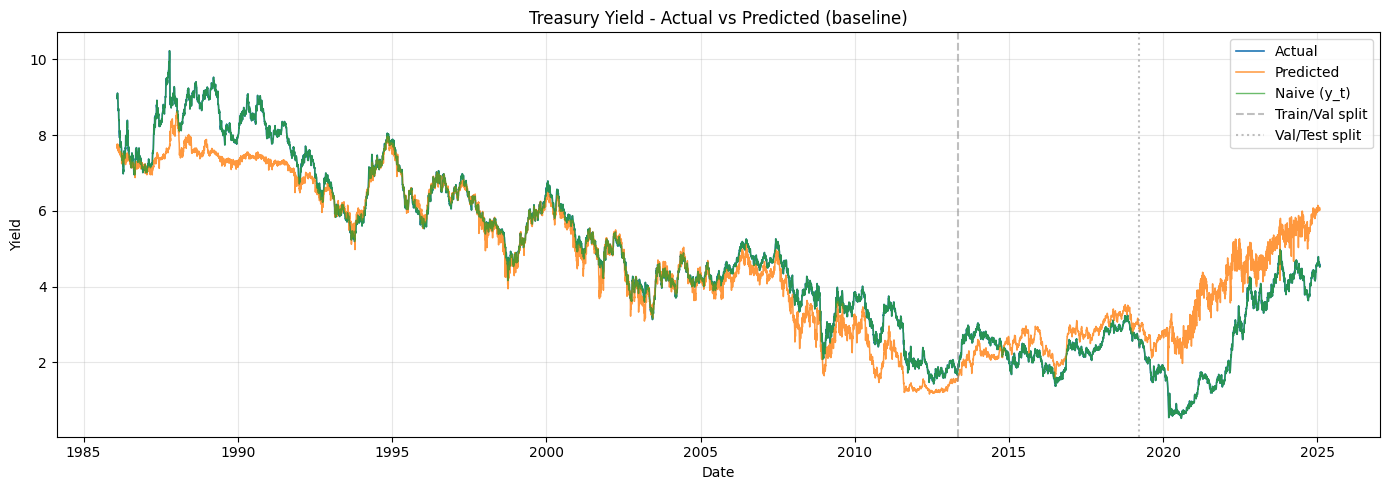

Baseline model RMSE: 1.6390 | MAE: 1.5089
Loaded tuned checkpoint from lstm_tuned.pt


C:\Users\santo\miniconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


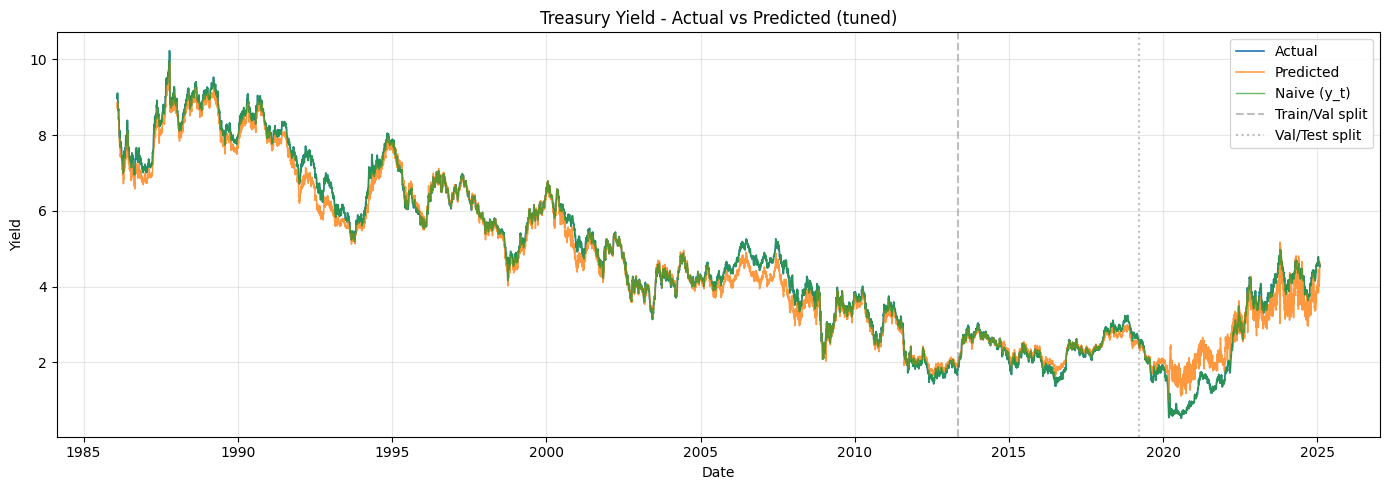


Persistence baseline (today's yield = next day)
                RMSE       MAE  Samples
Split                                  
Train       0.049032  0.032023     9991
Validation  0.033270  0.023126     2141
Test        0.045930  0.031335     2142
Tuned model RMSE: 0.5914 | MAE: 0.4991


In [9]:
def main():
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    df = load_dataframe(DATA_PATH)
    arrays, feature_cols, scalers, split_indices = split_and_scale(df)

    print(f"Loaded {len(df)} rows; features: {len(feature_cols)} | device: {DEVICE}")
    baseline_model = None
    if RUN_BASELINE:
        if not FORCE_BASELINE_RETRAIN and CHECKPOINT_BASELINE_PATH.exists():
            baseline_model, _, _ = load_checkpoint(str(CHECKPOINT_BASELINE_PATH), device=DEVICE)
            print(f"Loaded baseline checkpoint from {CHECKPOINT_BASELINE_PATH}")
        else:
            baseline_model = run_baseline(arrays, feature_cols, scalers)
        if PLOT_FULL_SERIES and baseline_model is not None:
            plot_full_series(
                df,
                split_indices,
                SEQ_LEN,
                baseline_model,
                arrays,
                scalers,
                title="Diff - Actual vs Predicted (baseline)",
            )


    if baseline_model is not None:
        print_model_metrics(baseline_model, SEQ_LEN, BATCH_SIZE, arrays, scalers, "Baseline model")
    tuned_model = None
    tuned_config = None
    if RUN_TUNING:
        if not FORCE_TUNED_RETRAIN and CHECKPOINT_TUNED_PATH.exists():
            tuned_model, tuned_config, _ = load_checkpoint(str(CHECKPOINT_TUNED_PATH), device=DEVICE)
            print(f"Loaded tuned checkpoint from {CHECKPOINT_TUNED_PATH}")
        else:
            tuned_model, tuned_config = run_tuning(arrays, feature_cols, scalers)
        if PLOT_FULL_SERIES and tuned_model is not None:
            plot_full_series(
                df,
                split_indices,
                SEQ_LEN,
                tuned_model,
                arrays,
                scalers,
                title="Diff - Actual vs Predicted (tuned)",
            )

    persistence_scores = persistence_baseline_scores(df, split_indices)
    print("\nPersistence baseline (zero target)")
    print(persistence_scores)

    if tuned_model is not None and tuned_config is not None:
        tuned_seq_len = tuned_config.get("seq_len", SEQ_LEN)
        tuned_batch = tuned_config.get("batch_size", BATCH_SIZE)
        print_model_metrics(tuned_model, tuned_seq_len, tuned_batch, arrays, scalers, "Tuned model")

if __name__ == "__main__":
    main()